# Feature Family Comparison

This notebook compares different feature representations for FI-2010 mid-price movement prediction.

The goal is to test whether engineered microstructure features add predictive value beyond the standard 144 FI-2010 benchmark features.

We compare:

1. Full 144 z-score benchmark features
2. Basic microstructure features
3. Rolling-context microstructure features without absolute price levels
4. Full 144 z-score features combined with rolling-context microstructure features

Each feature family is evaluated across all five FI-2010 forecast horizons.

In [ ]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from lob_forecasting.data import load_fi2010_split
from lob_forecasting.evaluation import evaluate_predictions_for_table
from lob_forecasting.features import build_microstructure_features
from lob_forecasting.models import get_default_model_builders

In [2]:
X_train_zscore, y_train_all, X_test_zscore, y_test_all = load_fi2010_split(
    project_root=PROJECT_ROOT,
    market="NoAuction",
    normalization="Zscore",
    cf=1,
    verbose=True,
)

X_train_decpre, y_train_all_decpre, X_test_decpre, y_test_all_decpre = load_fi2010_split(
    project_root=PROJECT_ROOT,
    market="NoAuction",
    normalization="DecPre",
    cf=1,
    verbose=True,
)

X_train: (39512, 144)
y_train_all: (39512, 5)
X_test: (38397, 144)
y_test_all: (38397, 5)
X_train: (39512, 144)
y_train_all: (39512, 5)
X_test: (38397, 144)
y_test_all: (38397, 5)


## Build feature families

We compare the original 144 FI-2010 benchmark features against engineered microstructure features. The microstructure features are built from DecPre data, while the 144 benchmark features come from the Zscore representation.

In [3]:
basic_train_features = build_microstructure_features(
    X_train_decpre,
    include_depth=True,
    include_context=False,
    remove_price_levels=False,
    fillna=True,
)

basic_test_features = build_microstructure_features(
    X_test_decpre,
    include_depth=True,
    include_context=False,
    remove_price_levels=False,
    fillna=True,
)

context_train_features = build_microstructure_features(
    X_train_decpre,
    include_depth=True,
    include_context=True,
    remove_price_levels=True,
    fillna=True,
)

context_test_features = build_microstructure_features(
    X_test_decpre,
    include_depth=True,
    include_context=True,
    remove_price_levels=True,
    fillna=True,
)

print("Zscore features:", X_train_zscore.shape, X_test_zscore.shape)
print("Basic microstructure:", basic_train_features.shape, basic_test_features.shape)
print("Context microstructure:", context_train_features.shape, context_test_features.shape)

Zscore features: (39512, 144) (38397, 144)
Basic microstructure: (39512, 11) (38397, 11)
Context microstructure: (39512, 20) (38397, 20)


In [5]:
zscore_train_df = pd.DataFrame(
    X_train_zscore,
    columns=[f"zscore_feature_{i}" for i in range(X_train_zscore.shape[1])]
)

zscore_test_df = pd.DataFrame(
    X_test_zscore,
    columns=[f"zscore_feature_{i}" for i in range(X_test_zscore.shape[1])]
)

In [6]:
combined_train_features = pd.concat(
    [
        zscore_train_df.reset_index(drop=True),
        context_train_features.reset_index(drop=True),
    ],
    axis=1
)

combined_test_features = pd.concat(
    [
        zscore_test_df.reset_index(drop=True),
        context_test_features.reset_index(drop=True),
    ],
    axis=1
)

In [7]:
feature_sets = {
    "zscore_144": (
        zscore_train_df,
        zscore_test_df,
    ),
    "basic_microstructure": (
        basic_train_features,
        basic_test_features,
    ),
    "context_microstructure_no_price": (
        context_train_features,
        context_test_features,
    ),
    "zscore_144_plus_context_microstructure": (
        combined_train_features,
        combined_test_features,
    ),
}

for name, (X_tr, X_te) in feature_sets.items():
    print(name, X_tr.shape, X_te.shape)

zscore_144 (39512, 144) (38397, 144)
basic_microstructure (39512, 11) (38397, 11)
context_microstructure_no_price (39512, 20) (38397, 20)
zscore_144_plus_context_microstructure (39512, 164) (38397, 164)


## Model definitions

We compare a linear baseline and a nonlinear tree-based model across each feature family and forecast horizon.

## Run feature-family comparison

Each feature family is evaluated across all five forecast horizons using the same models and the same official train/test split.

In [ ]:
model_builders = get_default_model_builders(include_majority=False)

results = []

for feature_set_name, (X_train_features, X_test_features) in feature_sets.items():
    print(f"Feature set: {feature_set_name}")

    for horizon in range(y_train_all.shape[1]):
        y_train = y_train_all[:, horizon].astype(int)
        y_test = y_test_all[:, horizon].astype(int)

        print(f"  Horizon {horizon}")

        for model_name, build_model in model_builders.items():
            print(f"    Training {model_name}")

            model = build_model()
            model.fit(X_train_features, y_train)

            y_pred = model.predict(X_test_features)

            row = evaluate_predictions_for_table(
                y_true=y_test,
                y_pred=y_pred,
                model_name=model_name,
                feature_set=feature_set_name,
                horizon=horizon,
            )

            results.append(row)

Feature set: zscore_144
  Horizon 0
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 1
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 2
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 3
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 4
    Training Logistic regression
    Training HistGradientBoosting
Feature set: basic_microstructure
  Horizon 0
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 1
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 2
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 3
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 4
    Training Logistic regression
    Training HistGradientBoosting
Feature set: context_microstructure_no_price
  Horizon 0
    Training Logistic regression
    Training HistGradientBoosting
  Horizon 1
    Training Log

In [11]:
feature_family_results = pd.DataFrame(results)

feature_family_results = feature_family_results.sort_values(
    ["horizon", "macro_f1"],
    ascending=[True, False]
)

feature_family_results

,feature_set,model,horizon,accuracy,macro_f1,f1_up,f1_flat,f1_down,support_up,support_flat,support_down
31,zscore_144_plus_context_microstructure,HistGradientBoosting,0,0.821392,0.774982,0.755752,0.873868,0.695325,8007,22699,7691
21,context_microstructure_no_price,HistGradientBoosting,0,0.812746,0.755201,0.740315,0.865279,0.660010,8007,22699,7691
30,zscore_144_plus_context_microstructure,Logistic regression,0,0.632836,0.611292,0.543873,0.691795,0.598210,8007,22699,7691
20,context_microstructure_no_price,Logistic regression,0,0.628721,0.607346,0.522632,0.688730,0.610675,8007,22699,7691
1,zscore_144,HistGradientBoosting,0,0.625674,0.491166,0.356223,0.766205,0.351072,8007,22699,7691
0,zscore_144,Logistic regression,0,0.414277,0.396816,0.341246,0.494234,0.354968,8007,22699,7691
11,basic_microstructure,HistGradientBoosting,0,0.568221,0.327761,0.157451,0.728210,0.097621,8007,22699,7691
10,basic_microstructure,Logistic regression,0,0.292315,0.290603,0.303057,0.308305,0.260449,8007,22699,7691
33,zscore_144_plus_context_microstructure,HistGradientBoosting,1,0.857020,0.844334,0.826525,0.888867,0.817611,10200,18486,9711
23,context_microstructure_no_price,HistGradientBoosting,1,0.704378,0.668781,0.623242,0.765945,0.617157,10200,18486,9711


In [12]:
summary_cols = [
    "horizon",
    "feature_set",
    "model",
    "accuracy",
    "macro_f1",
    "f1_up",
    "f1_flat",
    "f1_down",
]

feature_family_summary = feature_family_results[summary_cols]
feature_family_summary

,horizon,feature_set,model,accuracy,macro_f1,f1_up,f1_flat,f1_down
31,0,zscore_144_plus_context_microstructure,HistGradientBoosting,0.821392,0.774982,0.755752,0.873868,0.695325
21,0,context_microstructure_no_price,HistGradientBoosting,0.812746,0.755201,0.740315,0.865279,0.660010
30,0,zscore_144_plus_context_microstructure,Logistic regression,0.632836,0.611292,0.543873,0.691795,0.598210
20,0,context_microstructure_no_price,Logistic regression,0.628721,0.607346,0.522632,0.688730,0.610675
1,0,zscore_144,HistGradientBoosting,0.625674,0.491166,0.356223,0.766205,0.351072
0,0,zscore_144,Logistic regression,0.414277,0.396816,0.341246,0.494234,0.354968
11,0,basic_microstructure,HistGradientBoosting,0.568221,0.327761,0.157451,0.728210,0.097621
10,0,basic_microstructure,Logistic regression,0.292315,0.290603,0.303057,0.308305,0.260449
33,1,zscore_144_plus_context_microstructure,HistGradientBoosting,0.857020,0.844334,0.826525,0.888867,0.817611
23,1,context_microstructure_no_price,HistGradientBoosting,0.704378,0.668781,0.623242,0.765945,0.617157


## Observations

The feature-family comparison shows that rolling/context microstructure features provide the largest improvement over the original FI-2010 benchmark representation.

The basic microstructure feature set, which only uses current-snapshot quantities such as spread, imbalance, microprice deviation, and depth imbalance, performs substantially worse than the full 144-feature benchmark. This suggests that static order book pressure alone is not sufficient for reliable short-horizon prediction.

Adding recent-history context changes the result significantly. The context microstructure feature set, which includes recent mid-price returns, rolling volatility, rolling spread statistics, rolling imbalance, and rolling microprice-deviation statistics, outperforms the original 144-feature benchmark across all horizons.

The combined feature set, `zscore_144_plus_context_microstructure`, gives the best overall performance. This indicates that the engineered context features add predictive information beyond the standard FI-2010 representation.

HistGradientBoosting consistently outperforms logistic regression on the strongest feature sets, suggesting that nonlinear interactions between benchmark features and dynamic microstructure variables are important for short-horizon mid-price movement prediction.

The results also show that feature quality matters more than model complexity alone. Basic microstructure features with HGB are weaker than context microstructure features with logistic regression, indicating that recent-history features are central to predictive performance.

In [13]:
RESULTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR.mkdir(exist_ok=True)

output_path = RESULTS_DIR / "feature_family_results_cf1.csv"
feature_family_results.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: /Users/sohamaggarwal/Desktop/limit-order-book-forecasting/experiments/feature_family_results_cf1.csv


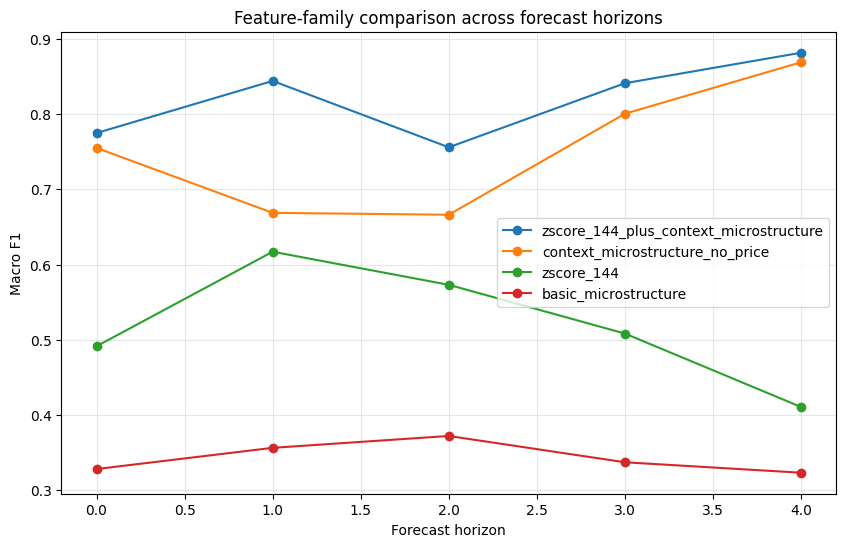

In [14]:
plt.figure(figsize=(10, 6))

for feature_set in feature_family_summary["feature_set"].unique():
    subset = feature_family_summary[
        (feature_family_summary["feature_set"] == feature_set)
        & (feature_family_summary["model"] == "HistGradientBoosting")
    ].sort_values("horizon")

    plt.plot(
        subset["horizon"],
        subset["macro_f1"],
        marker="o",
        label=feature_set,
    )

plt.xlabel("Forecast horizon")
plt.ylabel("Macro F1")
plt.title("Feature-family comparison across forecast horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()